# Set up notebook

In [37]:
import xarray as xr 
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

import cartopy.crs as ccrs
import pickle # For python object io
import glob

import importlib
import sys
util_path_top = '../util_files/'
sys.path.append(util_path_top)

import calculate_rho_w


In [35]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# Define functions

In [3]:
def fft_of_ds(data_for_fft,data_resolution):
    
    # Perform 1d fft
    fft_result = np.fft.fft(data_for_fft)
    
    # create spectral dimension (named like this as it could be both associated with space or time)
    spectral_dimension = np.fft.fftfreq(len(data_for_fft),data_resolution)
    ds_fft = xr.DataArray(np.abs(fft_result)**2, dims=['spectral_dimension'], coords={'spectral_dimension':spectral_dimension})
    
    ds_fft.loc[{'spectral_dimension':0}] = 0 # Remove DC component
    ds_fft_sorted = ds_fft.sortby(ds_fft.spectral_dimension).where(ds_fft.spectral_dimension >= 0,drop=True) # Keep only positive wavenumbers.
    
    return ds_fft_sorted

# Compute spectra

In [7]:
path_in = '/uolstore/Research/b/b0252/Data/cam6_2_011_CONUS/CONUS_RR_PROCESSED_DATA/reduced_data/1D_timeseries/'
path_out = '/uolstore/Research/b/b0252/Data/cam6_2_011_CONUS/CONUS_RR_PROCESSED_DATA/processed_data/spectra/omega_spectra/'

In [20]:
date_groups = [['2010-06-01', '2010-06-02', '2010-06-03', '2010-06-04', '2010-06-05']]
    # ['2010-06-06', '2010-06-07', '2010-06-08', '2010-06-09', '2010-06-10'],
    # ['2010-06-11', '2010-06-12', '2010-06-13', '2010-06-14', '2010-06-15'],
    # ['2010-06-16', '2010-06-17', '2010-06-18', '2010-06-19', '2010-06-20'],
    # ['2010-06-21', '2010-06-22', '2010-06-23', '2010-06-24', '2010-06-25'],
    # ['2010-06-26', '2010-06-27', '2010-06-28', '2010-06-29', '2010-06-30'],
    # ['2010-07-01', '2010-07-02', '2010-07-03', '2010-07-04', '2010-07-05'],
    # ['2010-07-06', '2010-07-07', '2010-07-08', '2010-07-09', '2010-07-10'],
    # ['2010-07-11', '2010-07-12', '2010-07-13', '2010-07-14', '2010-07-15'],
    # ['2010-07-16', '2010-07-17', '2010-07-18', '2010-07-19', '2010-07-20'],
    # ['2010-07-21', '2010-07-22', '2010-07-23', '2010-07-24', '2010-07-25'],
    # ['2010-07-26', '2010-07-27', '2010-07-28', '2010-07-29', '2010-07-30'],
    # ['2010-07-31', '2010-08-01', '2010-08-02', '2010-08-03', '2010-08-04'],
    # ['2010-08-05', '2010-08-06', '2010-08-07', '2010-08-08', '2010-08-09'],
    # ['2010-08-10', '2010-08-11', '2010-08-12', '2010-08-13', '2010-08-14'],
    # ['2010-08-15', '2010-08-16', '2010-08-17', '2010-08-18', '2010-08-19'],
    # ['2010-08-20', '2010-08-21', '2010-08-22', '2010-08-23', '2010-08-24'],
    # ['2010-08-25', '2010-08-26', '2010-08-27', '2010-08-28', '2010-08-29']]

varlist = ['w','T']

In [ ]:
save_spectra = False # flag to save spectra to netcdf files

In [24]:
# read in files corresponding to dates in date_groups
for date_group in date_groups:
    ds1_list = []
    ds2_list = []
    ii=1
    for date in date_group:
        ds_temp = xr.open_mfdataset(path_in+f'*_nonrr_*{date}*').squeeze() # read in nonrr data
        ds1_list.append(ds_temp)
        
        ds_temp = xr.open_mfdataset(path_in +f'*_rr_*{date}*').squeeze() # read in rr data
        ds2_list.append(ds_temp)
        print(f'Read in date {date} ({ii} of {len(date_group)})')
        ii+=1
        
    print('Read in all dates in date group')
    
    ds1 = xr.concat(ds1_list,dim='time')
    ds2 = xr.concat(ds2_list,dim='time')
    
    print('Concatenated all dates in date group')
    
    ds1['w'] = calculate_rho_w.converta_omega_to_w(ds1['OMEGA'], ds1['T'],ds1['lev'])
    ds2['w'] = calculate_rho_w.converta_omega_to_w(ds2['OMEGA'], ds2['T'],ds2['lev'])
    
    print('Converted omega to w')
    
    #
    # Compute spectra for all variables in varlist and save in spectral dataset.
    #
    
    # Create new dataset to hold all temporal spectra at each level
    ds_spec1 = xr.Dataset()
    ds_spec2 = xr.Dataset()
    
    # Loop over variables
    for var in varlist:
        
        # Empty lists to store spectra at each level
        spec_list1 = []
        spec_list2 = []
        for ilev in range(110):
            temp_spec = fft_of_ds(ds1[var].isel(lev=ilev).values,3600) # perform fft for data with 3600 second resolution 
            spec_list1.append(temp_spec)
            
            temp_spec = fft_of_ds(ds2[var].isel(lev=ilev).values,3600)
            spec_list2.append(temp_spec) 
            print(f'Computed spectra for {var} at level {ilev+1} of 110')
        
        # Save data in spectral dataset
        ds_spec1[f'{var}_spec'] = xr.concat(spec_list1,dim='lev')
        ds_spec2[f'{var}_spec'] = xr.concat(spec_list2,dim='lev')        
        
        print(f'Spectra done for {var}')
    
    # Finish setting up dataset
    
    ds_spec1['lev'] = ds1.lev.values
    ds_spec1['date_range'] = f'{date_group[0]} - {date_group[-1]}' # Add date range for reference
    ds_spec1 = ds_spec1.set_coords('date_range').expand_dims('date_range')

    ds_spec2['lev'] = ds2.lev.values
    ds_spec2['date_range'] = f'{date_group[0]} - {date_group[-1]}' # Add date range for reference
    ds_spec2 = ds_spec2.set_coords('date_range').expand_dims('date_range')

    # Save spectra
    if save_spectra:
        ds_spec1.to_netcdf(path_out + f'nonrr_w_T_U_V_omega_spectra_{date_group[0]}_{date_group[-1]}.nc')
        ds_spec2.to_netcdf(path_out + f'rr_w_T_U_V_omega_spectra_{date_group[0]}_{date_group[-1]}.nc')
        
    print(f'Spectra for {varlist} done between {date_group[0]}_{date_group[-1]}')


Read in date 2010-06-01 (1 of 5)
Read in date 2010-06-02 (2 of 5)
Read in date 2010-06-03 (3 of 5)
Read in date 2010-06-04 (4 of 5)
Read in date 2010-06-05 (5 of 5)
Read in all dates in date group
Concatenated all dates in date group
Converted omega to w
Computed spectra for w at level 1 of 110
Computed spectra for w at level 2 of 110
Computed spectra for w at level 3 of 110
Computed spectra for w at level 4 of 110
Computed spectra for w at level 5 of 110
Computed spectra for w at level 6 of 110
Computed spectra for w at level 7 of 110
Computed spectra for w at level 8 of 110
Computed spectra for w at level 9 of 110
Computed spectra for w at level 10 of 110
Computed spectra for w at level 11 of 110
Computed spectra for w at level 12 of 110
Computed spectra for w at level 13 of 110
Computed spectra for w at level 14 of 110
Computed spectra for w at level 15 of 110
Computed spectra for w at level 16 of 110
Computed spectra for w at level 17 of 110
Computed spectra for w at level 18 of 11

# Plot multiple spectra

In [31]:
path_in = '/uolstore/Research/b/b0252/Data/cam6_2_011_CONUS/CONUS_RR_PROCESSED_DATA/processed_data/spectra/omega_spectra/'

In [ ]:
ds_nonrr = xr.open_mfdataset(path_in + 'nonrr_*')
ds_rr = xr.open_mfdataset(path_in + 'rr_*')

In [33]:
ds_nonrr_mean = ds_nonrr.mean(dim='date_range')
ds_rr_mean = ds_rr.mean(dim='date_range')

<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:42: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3112024/1088388483.py:34: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frequency $\omega$/2$\pi$ (cyc/s)')
/tmp/ipykernel_3112024/1088388483.py:42: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frequency $\omega$/2$\pi$ (cyc/s)')


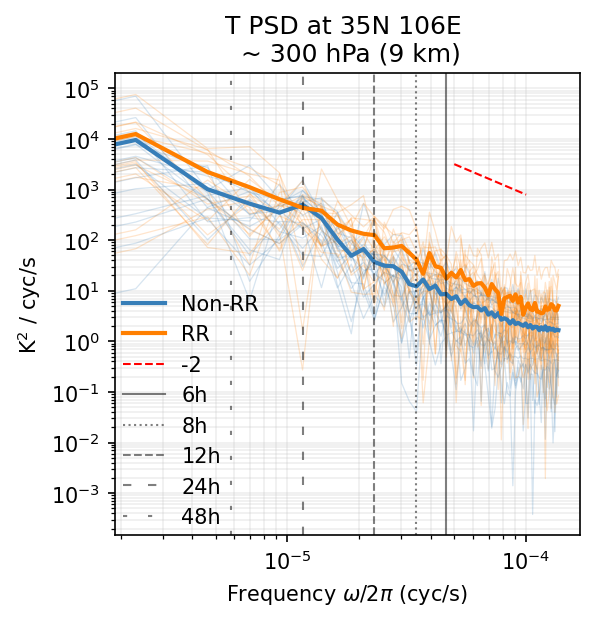

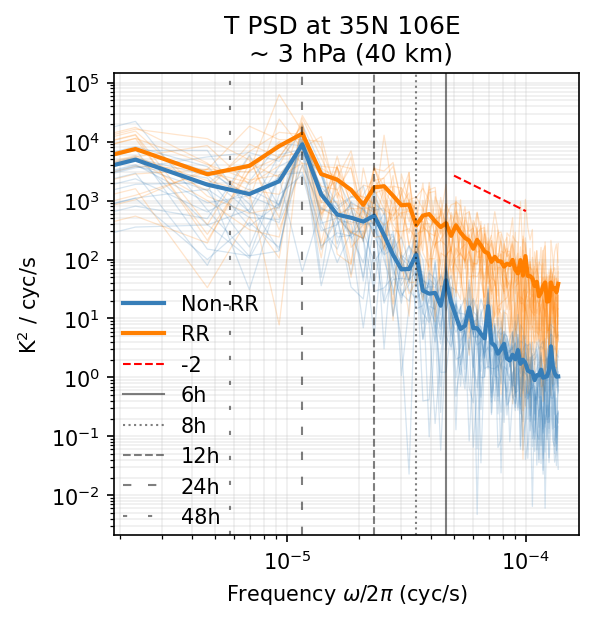

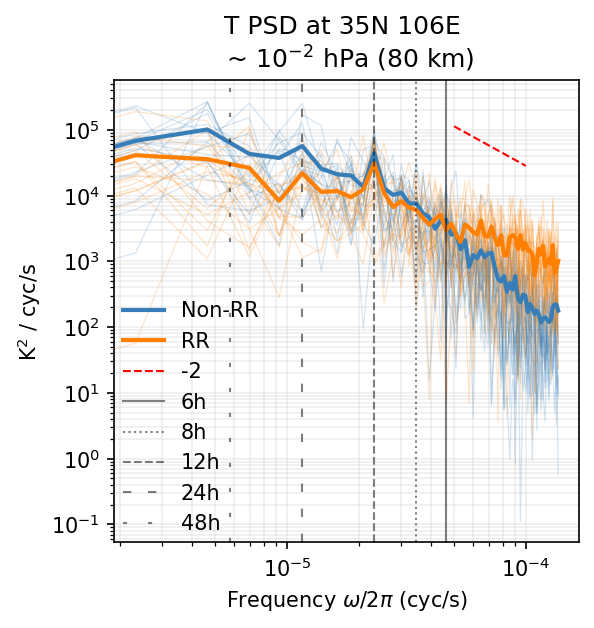

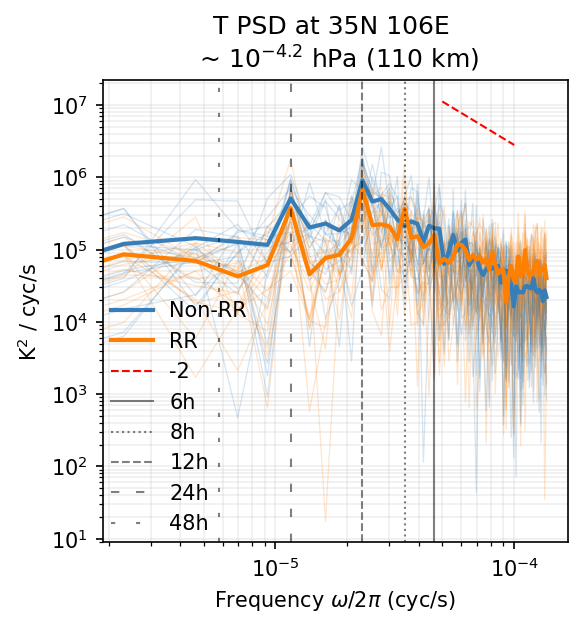

In [ ]:
var = 'T'

for i, lev in enumerate([300,3.1,8.8e-3,5.4e-5]): # loop over levels of interest
    plt.figure(figsize=(4,4),dpi=150)
    
    #
    # lev settings
    #
    if lev == 300: lev_str = '~ 300 hPa (9 km)' ; factor=1e-10 # for red dashed line on T spec, not used for w spec
    if lev == 3.1: lev_str = '~ 3 hPa (40 km)' ; factor = 1e-10
    if lev == 8.8e-3: lev_str = '~ 10$^{-2}$ hPa (80 km)' ; factor = 1e-9
    if lev == 5.4e-5: lev_str = '~ 10$^{-4.2}$ hPa (110 km)' ; factor = 1e-8
     
    for i in range(len(ds_nonrr.date_range)): # plot spectra for each date range
        ds_nonrr[f'{var}_spec'].sel(lev=lev,method='nearest').isel(date_range=i).plot(c=CB_color_cycle[0],linewidth=0.6,alpha=0.2)
        ds_rr[f'{var}_spec'].sel(lev=lev,method='nearest').isel(date_range=i).plot(c=CB_color_cycle[1],linewidth=0.6,alpha=0.2)
    
    # Plot mean spectra
    ds_nonrr_mean[f'{var}_spec'].sel(lev=lev,method='nearest').plot(c=CB_color_cycle[0],linewidth=2,label='Non-RR')
    ds_rr_mean[f'{var}_spec'].sel(lev=lev,method='nearest').plot(c=CB_color_cycle[1],linewidth=2,label='RR')  
        
    #
    # Set up title and labels
    #
    
    #
    # w
    #
    if var == 'w':
        plt.title('w PSD at 35N 106E \n' + lev_str)
        plt.ylabel('m$^2$/s$^2$ / cyc/s')
        plt.xlabel('Frequency $\omega$/2$\pi$ (cyc/s)')

    #
    # T
    #
    if var == 'T':
        plt.title('T PSD at 35N 106E \n ' + lev_str)
        plt.ylabel('K$^2$ / cyc/s')
        plt.xlabel('Frequency $\omega$/2$\pi$ (cyc/s)')
        x = np.logspace(np.log10(5e-5),np.log10(1e-4),100)
        ax = plt.gca()
        ylimU = ax.axes.get_ylim()[1]
        y = factor*ylimU*x**(-2)
        plt.plot(x,y,c='r',linewidth=1,linestyle='--', label='-2')
    
    
    #
    # Plot lines for various time periods
    #

    plt.grid(True,alpha=0.2,which='both')
    plt.axvline(1/(6*3600),linewidth=1,c='k',alpha=0.5, linestyle='-',label='6h')
    plt.axvline(1/(8*3600),linewidth=1,c='k',alpha=0.5, linestyle=':',label='8h')
    plt.axvline(1/(12*3600),linewidth=1,c='k',alpha=0.5, linestyle='--',label='12h')
    plt.axvline(1/(24*3600),linewidth=1,c='k',alpha=0.5, linestyle=(0, (4, 8)),label='24h')
    plt.axvline(1/(48*3600),linewidth=1,c='k',alpha=0.5, linestyle=(0, (2, 10)),label='48h') 
    
    plt.xscale('log')
    plt.yscale('log')     
    
    plt.legend(framealpha=0,fontsize=10,loc=[0,0])      
    
